In [2]:
import pandas as pd
df = pd.read_csv("C:\\Users\\DELL\\Music\\customer-churn-ml\\Telco_customer_churn.csv", usecols = ["tenure","MonthlyCharges","TotalCharges","Contract","InternetService","PaymentMethod","Churn"])
df.head(5)

,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,DSL,Month-to-month,Electronic check,29.85,29.85,No
1,34,DSL,One year,Mailed check,56.95,1889.5,No
2,2,DSL,Month-to-month,Mailed check,53.85,108.15,Yes
3,45,DSL,One year,Bank transfer (automatic),42.30,1840.75,No
4,2,Fiber optic,Month-to-month,Electronic check,70.70,151.65,Yes


In [3]:
df.isnull().sum()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           7043 non-null   int64  
 1   InternetService  7043 non-null   object 
 2   Contract         7043 non-null   object 
 3   PaymentMethod    7043 non-null   object 
 4   MonthlyCharges   7043 non-null   float64
 5   TotalCharges     7043 non-null   object 
 6   Churn            7043 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 385.3+ KB


In [4]:
df['TotalCharges']=  pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

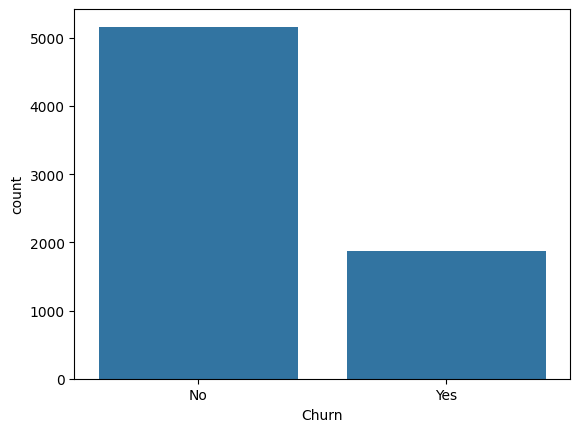

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Churn', data=df)
plt.show()

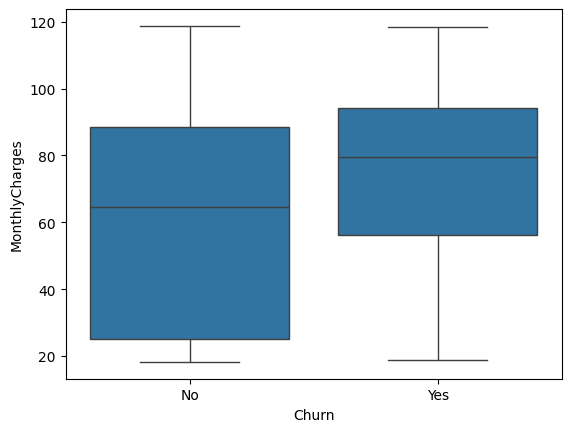

In [6]:

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()


In [7]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df_encoded = pd.get_dummies(df, drop_first=True)

In [8]:
from sklearn.model_selection import train_test_split
y = df_encoded['Churn']
X = df_encoded.drop('Churn', axis=1)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
y_train




6030    1
3410    1
5483    1
5524    0
6337    0
       ..
3778    0
5199    0
5235    0
5399    0
862     1
Name: Churn, Length: 5625, dtype: int64

In [9]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7931769722814499
[[921 112]
 [179 195]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [11]:
import numpy as np

importance = model.coef_[0]
features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance.head()


,Feature,Importance
3,InternetService_Fiber optic,0.993486
8,PaymentMethod_Electronic check,0.399654
2,TotalCharges,0.000362
1,MonthlyCharges,-0.003384
0,tenure,-0.061148


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# rf_model.predict(X_train[0])
a = rf_model.predict([[43,50,2902,False,False,False,False,False,False,False]])
a[0]

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


np.int64(0)

In [28]:
y_test[6125]

np.int64(1)

In [13]:
from sklearn.metrics import classification_report

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1033
           1       0.55      0.44      0.49       374

    accuracy                           0.76      1407
   macro avg       0.68      0.66      0.67      1407
weighted avg       0.74      0.76      0.75      1407



In [29]:
import joblib
joblib.dump(rf_model, open("rf.joblib", "wb"))

In [30]:
model=joblib.load("rf.joblib")
model.predict([[43,50,2902,False,False,False,False,False,False,False]])

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [17]:
X_test

,tenure,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2481,61,25.00,1501.75,False,True,False,True,False,False,False
6784,19,24.70,465.85,False,True,False,False,False,False,False
6125,13,102.25,1359.00,True,False,False,False,True,False,False
3052,37,55.05,2030.75,False,False,False,False,False,False,True
4099,6,29.45,161.45,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1733,1,19.05,19.05,False,True,False,False,False,False,True
5250,12,94.55,1173.55,True,False,False,False,False,True,False
5465,26,56.05,1553.20,False,False,True,False,False,False,True
5851,35,110.80,3836.30,True,False,True,False,False,False,False


In [18]:
X_test.columns


Index(['tenure', 'MonthlyCharges', 'TotalCharges',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')